# Feature-axis validation — merged CircuitNet-N14 + N28

Cross-node replication of the per-dataset analyses. Both N14 and N28 factorial
design matrices are parsed into a **single unified schema**, then run through
the same PCA → η² decomposition → clustering (K-means + Ward) →
per-cluster distribution → kNN label agreement pipeline used in the
per-dataset notebooks. The additional question here is: **does the
technology node (28nm vs 14nm) dominate as a cross-cutting FL client axis on
top of `design_name`?**

## Merge decisions (frozen)

| factor | N28 raw | N14 raw | unified in this notebook |
|---|---|---|---|
| `design_name` | 6 levels with `-a`/`-b` variants | 5 levels, no variants | **kept raw** — 11 distinct designs, sparse cross-node overlap (Q1 = b) |
| `freq_mhz` | derived from `clock_ns` via 1000/ns | native | single unified column, values {50, 200, 500} MHz |
| `utilization` | fractions 0.70–0.90 | percentages 50–75 | N14 divided by 100 → fractions, marginal overlap zone 0.70–0.75 |
| `aspect_ratio` | absent (square dies) | {1.0, 1.5, 2.0} | imputed **1.0** for all N28 rows |
| `macro_count` | {1, 2, 3} | absent | **dropped** — no analogue in N14 |
| `filler_insertion` | `'0'`/`'1'` (0 = after routing, 1 = after placement) | `'ap'`/`'ar'` | mapped: N28 `'1'` → `'ap'`, `'0'` → `'ar'` |
| `power_mesh` | `'1'…'8'` | `'0'…'7'` | kept as-is (categorical) |
| `macro_placement` | `'1'…'4'` | `'1'…'4'` | direct merge |
| `tech_node` | 28nm implicit | 14nm implicit | **added** as first-class factor `{'28nm','14nm'}` |

## Predictions (frozen before running)

1. **`tech_node` will dominate PC1.** Almost every downstream factor
   differs between the two nodes (different design set, different
   utilization range, different filler encoding), so the strongest single
   axis in the merged geometry should be "which dataset did this sample
   come from".
2. **`design_name` remains second-place**, structuring PC2 and beyond.
3. **`freq_mhz` and `utilization`** show a cleaner cross-node signal here
   than in either single-dataset notebook, because the merged range is
   wider.
4. **`macro_placement`, `power_mesh`, `filler_insertion`** stay near-noise
   as in the per-dataset analyses.

## Workflow

1. Parse N28 and N14 filenames with two dedicated parsers, then concat into
   one dataframe with the unified schema.
2. One-hot `design_name` + `filler_insertion` + `tech_node`, QuantileTransform
   + StandardScaler + 15-component PCA.
3. Loadings + recolored PC1/PC2 scatter (with `tech_node` as an extra colouring).
4. Variance-weighted η² decomposition.
5. Clustering + neighbourhood probes: K-means (sweep + manual k), Ward,
   per-cluster distribution, kNN label agreement.
6. Final verdict + N14/N28 cross-comparison.

# Imports

In [ ]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 3D plot of the first three PCs, colored by cluster label and by two key metadata factors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _scatter3d(ax, values, cmap, title, cbar_ticks=None, cbar_labels=None):
    sc = ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=values, cmap=cmap,
                    s=6, alpha=0.7, edgecolor='none', depthshade=False)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.08,
                        ticks=cbar_ticks)
    if cbar_labels is not None:
        cbar.set_ticklabels(cbar_labels)
        cbar.ax.tick_params(labelsize=7)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

N28_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
N14_DIR = '../routability_ir_drop_prediction/training_set_N14/DRC/feature'
SEED = 42
print('Imports OK.')

Imports OK.


# Parse filenames → unified factorial design matrix

Two dedicated parsers — one per naming convention — build a row per sample
with the unified schema. `filename` is kept for traceability; `dataset` is
the same as `tech_node` and is added for convenience when filtering later.

Merge rules applied here (per the header table):

- N28 `clock_ns` → `freq_mhz = 1000 / clock_ns` (2 → 500, 5 → 200, 20 → 50).
- N14 `utilization` divided by 100 to match N28's fraction scale.
- N28 rows get `aspect_ratio = 1.0` (square dies).
- N28 `filler_insertion` `'1'` / `'0'` → `'ap'` / `'ar'`.
- `tech_node` set to `'28nm'` for N28 rows, `'14nm'` for N14 rows.
- `macro_count` dropped from N28 (no N14 analogue).

In [ ]:
def parse_n28(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c', 'u', 'm', 'p', 'f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    clock_ns = float(c[1:])
    fi_raw = f[1:]
    return {
        'design_name':      '-'.join(parts[:-6]),  # keep -a/-b (Q1 = b)
        'freq_mhz':         1000.0 / clock_ns,     # Q2 = a
        'macro_placement':  m[1:],
        'utilization':      float(u[1:]),          # already fraction
        'aspect_ratio':     1.0,                   # Q4 = a (impute square)
        'power_mesh':       p[1:],
        'filler_insertion': fi_raw,  # Q6 = a
        'tech_node':        '28nm',                # Q8 = a
        'dataset':          'N28',
        'filename':         filename,
    }


def parse_n14(filename: str) -> dict:
    basename = filename.removesuffix('.npy')
    design_name, sep, rest = basename.partition('_freq_')
    parts = rest.split('_')
    if not (design_name and sep and len(parts) == 11):
        raise ValueError(f'Cannot parse {filename}')
    for expected, token in zip(['mp', 'fpu', 'fpa', 'p', 'fi'], parts[1::2]):
        if token != expected:
            raise ValueError(f'Bad token {token} in {filename}')
    mp, u, ar, pm, fi = parts[2::2]
    return {
        'design_name':      design_name,
        'freq_mhz':         float(parts[0]),
        'macro_placement':  mp,
        'utilization':      float(u) / 100.0,
        'aspect_ratio':     float(ar),
        'power_mesh':       pm,
        'filler_insertion': 1 if fi == 'ap' else 0,
        'tech_node':        '14nm',
        'dataset':          'N14',
        'filename':         filename,
    }


n28_files = sorted(f for f in os.listdir(N28_DIR) if f.endswith('.npy'))
n14_files = sorted(f for f in os.listdir(N14_DIR) if f.endswith('.npy'))

rows = [parse_n28(f) for f in n28_files] + [parse_n14(f) for f in n14_files]
df_meta = pd.DataFrame(rows)
df_meta.loc[~df_meta['macro_placement'].isin(['1', '2', '3', '4']),
            'macro_placement'] = '1'

FACTOR_COLS = [
    'design_name',
    'freq_mhz',
    'macro_placement',
    'utilization',
    'aspect_ratio',
    'power_mesh',
    'filler_insertion',
    'tech_node',
]
print(f'Total samples: {len(df_meta)}   '
      f'(N28: {(df_meta.dataset == "N28").sum()},   '
      f'N14: {(df_meta.dataset == "N14").sum()})')
print('\nUnique-value counts per factor:')
for c in FACTOR_COLS:
    n = df_meta[c].nunique()
    print(f'  {c:20s} {n:3d}')

print('\nHead:')
print(df_meta[FACTOR_COLS + ['dataset']].head(3))
print('\nTail:')
print(df_meta[FACTOR_COLS + ['dataset']].tail(3))

print('\nSanity — cross-node overlap of shared factor levels:')
for c in ['design_name', 'freq_mhz', 'macro_placement',
          'utilization', 'aspect_ratio', 'power_mesh', 'filler_insertion']:
    n28_vals = set(df_meta.loc[df_meta.dataset == 'N28', c].astype(str).unique())
    n14_vals = set(df_meta.loc[df_meta.dataset == 'N14', c].astype(str).unique())
    shared   = sorted(n28_vals & n14_vals)
    n28_only = sorted(n28_vals - n14_vals)
    n14_only = sorted(n14_vals - n28_vals)
    print(f'  {c:20s} shared={shared}   N28-only={n28_only}   N14-only={n14_only}')

Total samples: 19787   (N28: 10242,   N14: 9545)

Unique-value counts per factor:
  design_name           11
  freq_mhz               3
  macro_placement        4
  utilization            9
  aspect_ratio           3
  power_mesh             9
  filler_insertion       4
  tech_node              2

Head:
  design_name  freq_mhz macro_placement  utilization  aspect_ratio power_mesh  \
0     RISCY-a     500.0               1         0.70           1.0          1   
1     RISCY-a     500.0               2         0.70           1.0          2   
2     RISCY-a     500.0               2         0.85           1.0          3   

  filler_insertion tech_node dataset  
0                0      28nm     N28  
1                0      28nm     N28  
2                0      28nm     N28  

Tail:
      design_name  freq_mhz macro_placement  utilization  aspect_ratio  \
19784  zero-riscy      50.0               4         0.75           2.0   
19785  zero-riscy      50.0               4         0.75   

# Preprocess + PCA

One-hot the three categorical factors — `design_name` (11 levels),
`filler_insertion` (2 levels), `tech_node` (2 levels) — giving 15 one-hot
columns. Combine with the 5 numeric factors (`freq_mhz`,
`macro_placement`, `utilization`, `aspect_ratio`, `power_mesh` — the last
two categorical string columns get coerced to float by
`QuantileTransformer`).

Total design-matrix width = 11 + 2 + 2 + 5 = **20 columns**. Ask for 20 PCs;
the last few will be numerically zero due to sum-to-one collinearity from
each one-hot group.

Same preprocessing as the per-dataset notebooks: `QuantileTransformer`
(Gaussian output) → `StandardScaler` → PCA.

Design-matrix columns:
  freq_mhz
  macro_placement
  utilization
  aspect_ratio
  power_mesh
  filler_insertion
  design_name_RISCY
  design_name_RISCY-FPU
  design_name_RISCY-FPU-a
  design_name_RISCY-FPU-b
  design_name_RISCY-a
  design_name_RISCY-b
  design_name_Vortex-small
  design_name_nvdla-small
  design_name_zero-riscy
  design_name_zero-riscy-a
  design_name_zero-riscy-b
  tech_node_14nm
  tech_node_28nm

Explained variance ratio (19 components):
  PC 1: 0.223   cumulative=0.223
  PC 2: 0.064   cumulative=0.287
  PC 3: 0.063   cumulative=0.349
  PC 4: 0.062   cumulative=0.412
  PC 5: 0.059   cumulative=0.471
  PC 6: 0.059   cumulative=0.529
  PC 7: 0.058   cumulative=0.588
  PC 8: 0.057   cumulative=0.645
  PC 9: 0.056   cumulative=0.701
  PC10: 0.053   cumulative=0.754
  PC11: 0.052   cumulative=0.806
  PC12: 0.048   cumulative=0.854
  PC13: 0.046   cumulative=0.900
  PC14: 0.045   cumulative=0.945
  PC15: 0.032   cumulative=0.977
  PC16: 0.023   cumulative=1.000
  PC17: 0.

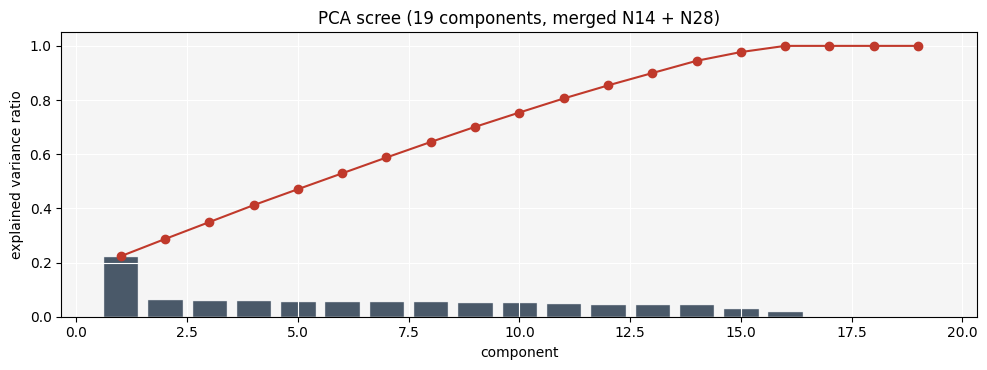

In [14]:
subset = df_meta
new_subset = pd.get_dummies(
    subset,
    columns=['design_name', 'tech_node'],
    dtype='uint8',
)
new_subset = new_subset.drop(columns=['filename', 'dataset'])
print('Design-matrix columns:')
for c in new_subset.columns:
    print(f'  {c}')

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X_qt)

N_PC = X_std.shape[1]
pca = PCA(n_components=N_PC, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print(f'\nExplained variance ratio ({N_PC} components):')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(range(1, N_PC + 1), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, N_PC + 1), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title(f'PCA scree ({N_PC} components, merged N14 + N28)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2 scatter

Print top-10 absolute loadings on PC1/PC2/PC3, then plot PC1 vs PC2 six
times, one per factor (adding `tech_node` on top of the five used in the
single-dataset notebooks). A factor that produces cleanly separated
regions in PC1/PC2 is one the leading PCs encode directly.

**Prediction to verify:** PC1 should be dominated by `tech_node` — the
factor that touches every column of the merged schema differently.

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['tech_node', 'design_name', 'macro_placement',
                   'utilization', 'freq_mhz', 'power_mesh']

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(22, 12))
for i, factor in enumerate(recolor_factors):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap='viridis',
                         s=6, alpha=0.7, edgecolor='none', depthshade=False)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.08, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap=cmap,
                         s=6, alpha=0.7, edgecolor='none', depthshade=False,
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)),
                            fraction=0.03, pad=0.08)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 / PC2 / PC3 — colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()

df_full = subset

# Variance decomposition — variance-weighted η²

Same per-PC one-way ANOVA + variance-weighted sum as the per-dataset
notebooks. Ranks every factor by how much of the merged design-matrix
variance it explains.

**Reading guide.** `tech_node` is the newcomer and should sit near the top
if the merge produced a strong cross-dataset signal. `design_name` should
still be high (11 one-hot columns worth of head start). Everything else
should sit in a narrower band as in the per-dataset notebooks.

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  eta2_PC12  eta2_PC13  eta2_PC14  eta2_PC15  eta2_PC16  eta2_PC17  eta2_PC18  eta2_PC19  weighted_total
     design_name        11     0.954     0.648     0.997     0.999     0.915     0.961     0.997     0.795     0.975      0.980      0.200      0.312      0.017      0.170      0.035      0.044        0.0        0.0      0.000           0.735
       tech_node         2     0.952     0.003     0.000     0.000     0.000     0.000     0.000     0.001     0.000      0.000      0.000      0.000      0.004      0.000      0.007      0.032        0.0        0.0      0.000           0.214
     utilization         9     0.674     0.023     0.000     0.000     0.004     0.002     0.000     0.011     0.006      0.001      0.011      0.003      0.025      0.002      0.622      0.080        0.0        0.0      0.001           0.177
    aspect_ratio         3  

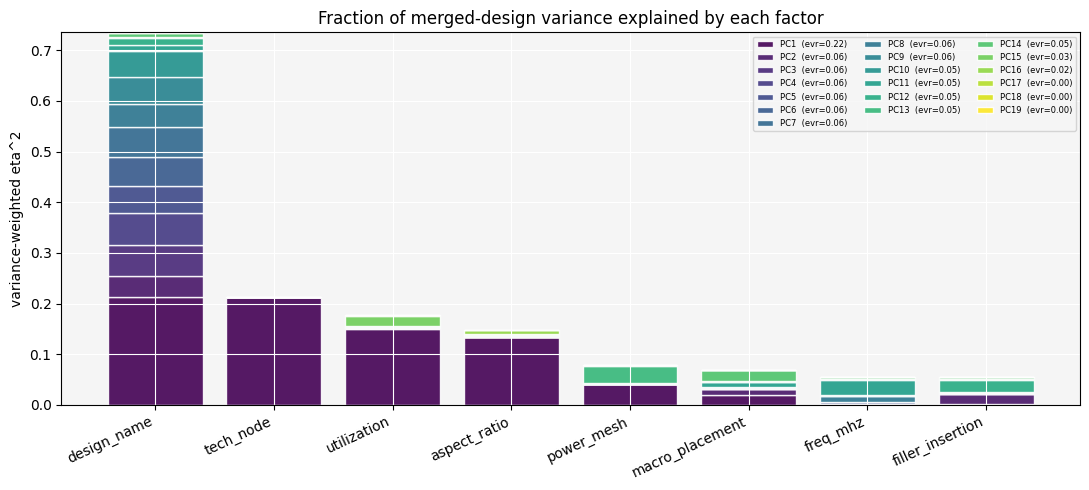

In [ ]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of merged-design variance explained by each factor')
ax.legend(fontsize=6, loc='upper right', ncol=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Clustering + neighborhood diagnostics

Same three-part approach as the per-dataset notebooks:

1. **K-means** — silhouette sweep to find the natural cluster count, then
   fit at a manually-chosen `k_design` and score ARI/NMI vs every factor.
2. **Ward hierarchical** — dendrogram + ARI/NMI at the same k for cross-check.
3. **Per-cluster factor distributions** (tables + stacked bar charts).
4. **kNN label agreement** — model-free per-factor local purity vs chance.

Same convention as the per-dataset notebooks: `Z3 = Z` (the full PC space —
the `3` in the name is stale but preserved for parity).

## K-means — k sweep + label agreement

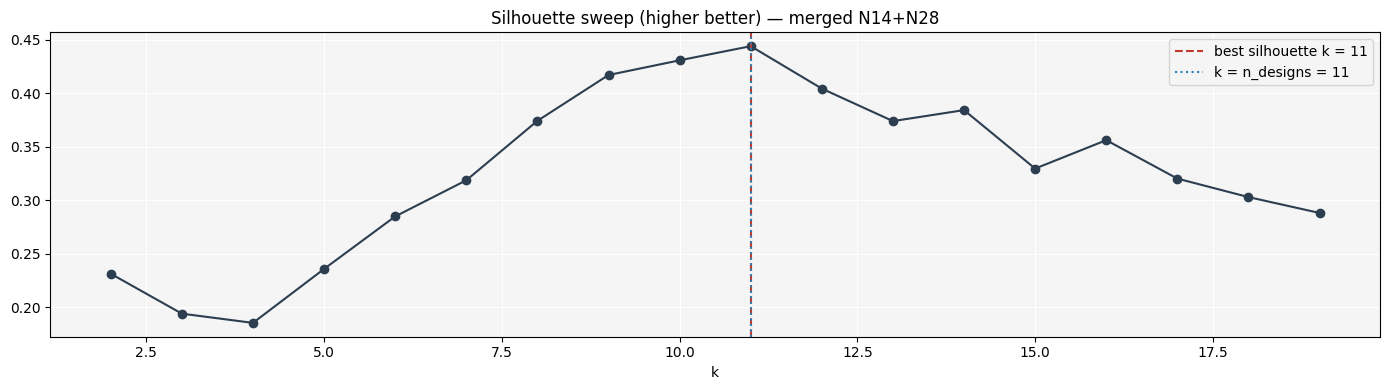

Best-silhouette k = 11   (silhouette = 0.444)
n_designs      k = 11   (silhouette = 0.444)


In [17]:
Z3 = Z  # full PC space, name kept for parity with per-dataset notebooks
k_design = df_full['design_name'].nunique()

ks = list(range(2, 20))
sil = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ks, sil, marker='o', color='#2c3e50')
ax.axvline(k_best_sil, ls='--', color='#c0392b',
           label=f'best silhouette k = {k_best_sil}')
ax.axvline(k_design, ls=':', color='#2980b9',
           label=f'k = n_designs = {k_design}')
ax.set_title('Silhouette sweep (higher better) — merged N14+N28')
ax.set_xlabel('k'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')
print(f'n_designs      k = {k_design}   (silhouette = {sil[ks.index(k_design)]:.3f})')

In [18]:
# SET K HERE
k_design = k_best_sil
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 11 for clustering and evaluation.



ARI / NMI of k-means labels (k=11) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=+0.002  NMI=0.011
  macro_placement      ARI=+0.004  NMI=0.033
  utilization          ARI=+0.058  NMI=0.204
  aspect_ratio         ARI=+0.033  NMI=0.212
  power_mesh           ARI=+0.009  NMI=0.044
  filler_insertion     ARI=+0.001  NMI=0.006
  tech_node            ARI=+0.243  NMI=0.483


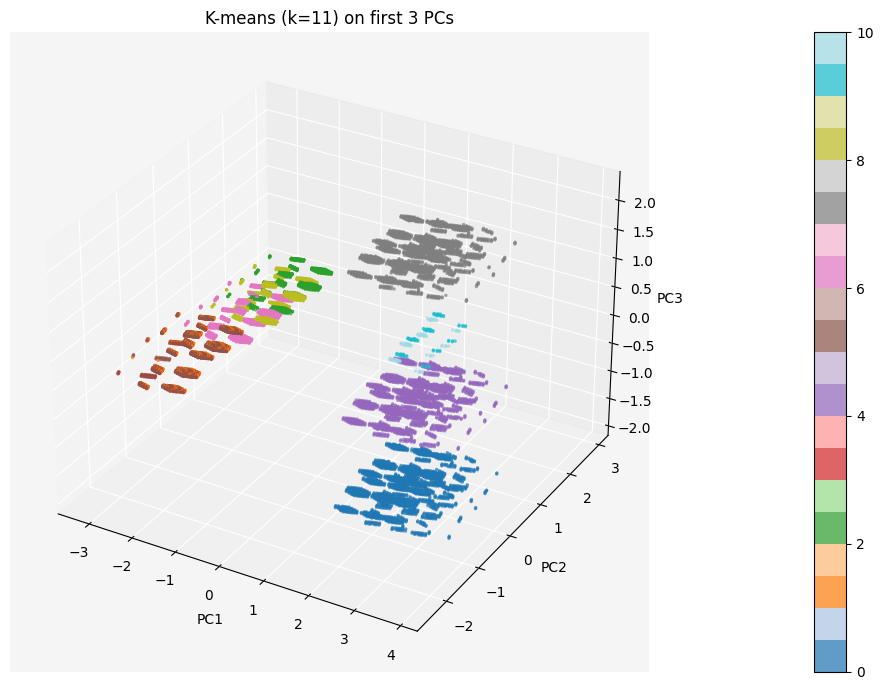

In [25]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig = plt.figure(figsize=(21, 7))

_scatter3d(fig.add_subplot(1, 1, 1, projection='3d'),
           lab_km, 'tab20',
           f'K-means (k={k_design}) on first 3 PCs')

plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

Ward linkage cut at the same `k_design` chosen above. Cross-check for
k-means, plus a dendrogram to see whether `tech_node` splits sit above or
below `design_name` splits in the tree.

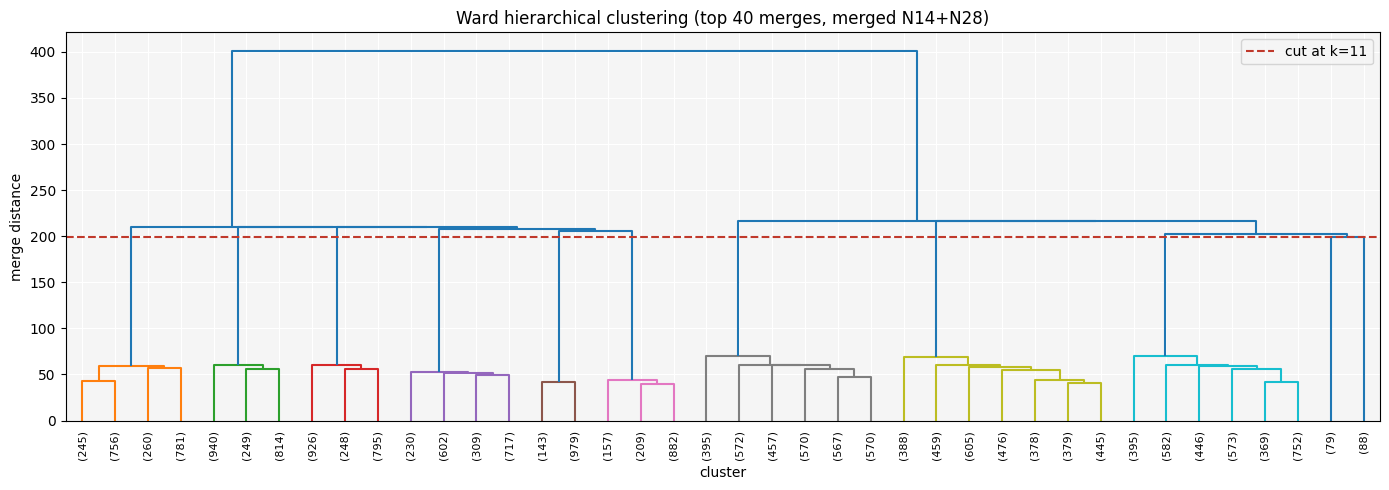

Hierarchical @ k=11   silhouette = 0.444   (k-means @ k=11 silhouette = 0.444)

ARI / NMI of hierarchical labels (k=11) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  freq_mhz             ARI=+0.002  NMI=0.011
  macro_placement      ARI=+0.004  NMI=0.033
  utilization          ARI=+0.058  NMI=0.204
  aspect_ratio         ARI=+0.033  NMI=0.212
  power_mesh           ARI=+0.009  NMI=0.044
  filler_insertion     ARI=+0.001  NMI=0.006
  tech_node            ARI=+0.243  NMI=0.483


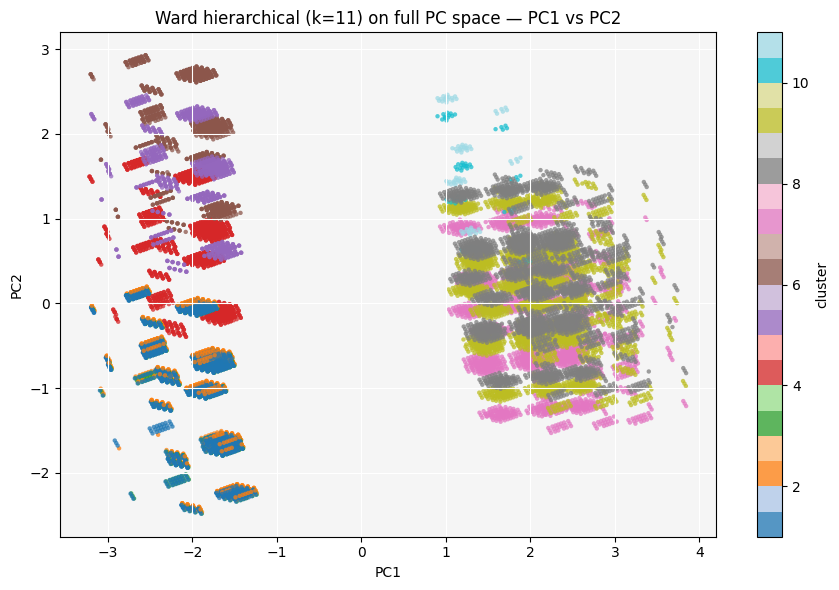

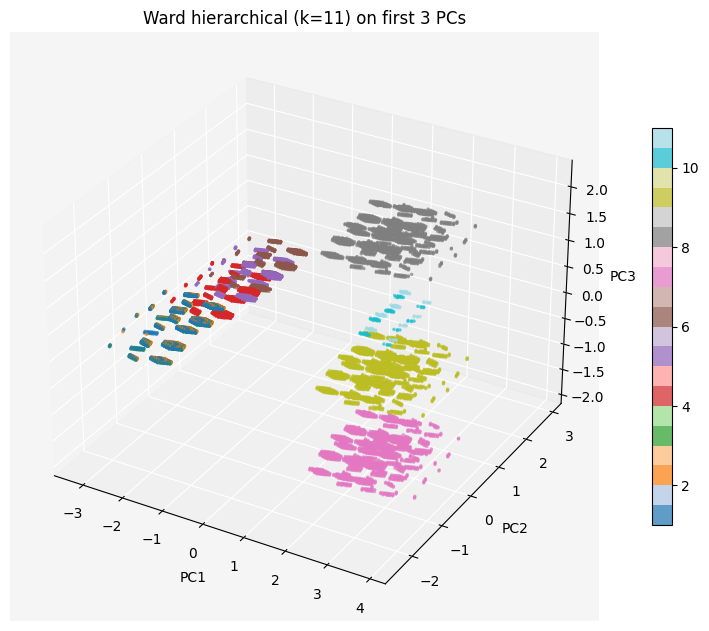

In [24]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_link, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8, ax=ax,
           color_threshold=Z_link[-(k_design - 1), 2])
ax.axhline(Z_link[-(k_design - 1), 2], ls='--', color='#c0392b',
           label=f'cut at k={k_design}')
ax.set_title(f'Ward hierarchical clustering (top 40 merges, merged N14+N28)')
ax.set_xlabel('cluster'); ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}   silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_hier, cmap='tab20',
                 s=10, alpha=0.75, edgecolor='none')
ax.set_title(f'Ward hierarchical (k={k_design}) on full PC space — PC1 vs PC2')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout(); plt.show()


# 3D plot of the first three PCs, colored by cluster label and by two key metadata factors
fig = plt.figure(figsize=(21, 7))

_scatter3d(fig.add_subplot(1, 3, 1, projection='3d'),
           lab_hier, 'tab20',
           f'Ward hierarchical (k={k_design}) on first 3 PCs')

plt.tight_layout(); plt.show()

## Per-cluster feature distribution

For every cluster from both K-means and Ward, print the % of samples at
each level of each factor (crosstab table) and plot a stacked-bar grid.
The `tech_node` bar is the diagnostic to watch: if clusters are ~100 %
one node, the merge produced a clean node-level split; if they mix, the
`design_name` or a shared factor is the real cluster driver.


K-means (k = 11): per-cluster feature distribution

Cluster sizes: {0: 3131, 1: 2003, 2: 1248, 3: 1969, 4: 3117, 5: 2042, 6: 1858, 7: 3130, 8: 1122, 9: 88, 10: 79}   (total = 19787)

--- design_name   (% within each cluster) ---
design_name  RISCY  RISCY-FPU  RISCY-FPU-a  RISCY-FPU-b  RISCY-a  RISCY-b  Vortex-small  nvdla-small  zero-riscy  zero-riscy-a  zero-riscy-b
cluster                                                                                                                                     
0              0.0      100.0          0.0          0.0      0.0      0.0           0.0          0.0         0.0           0.0           0.0
1              0.0        0.0          0.0          0.0    100.0      0.0           0.0          0.0         0.0           0.0           0.0
2              0.0        0.0          0.0        100.0      0.0      0.0           0.0          0.0         0.0           0.0           0.0
3              0.0        0.0        100.0          0.0      0.0 

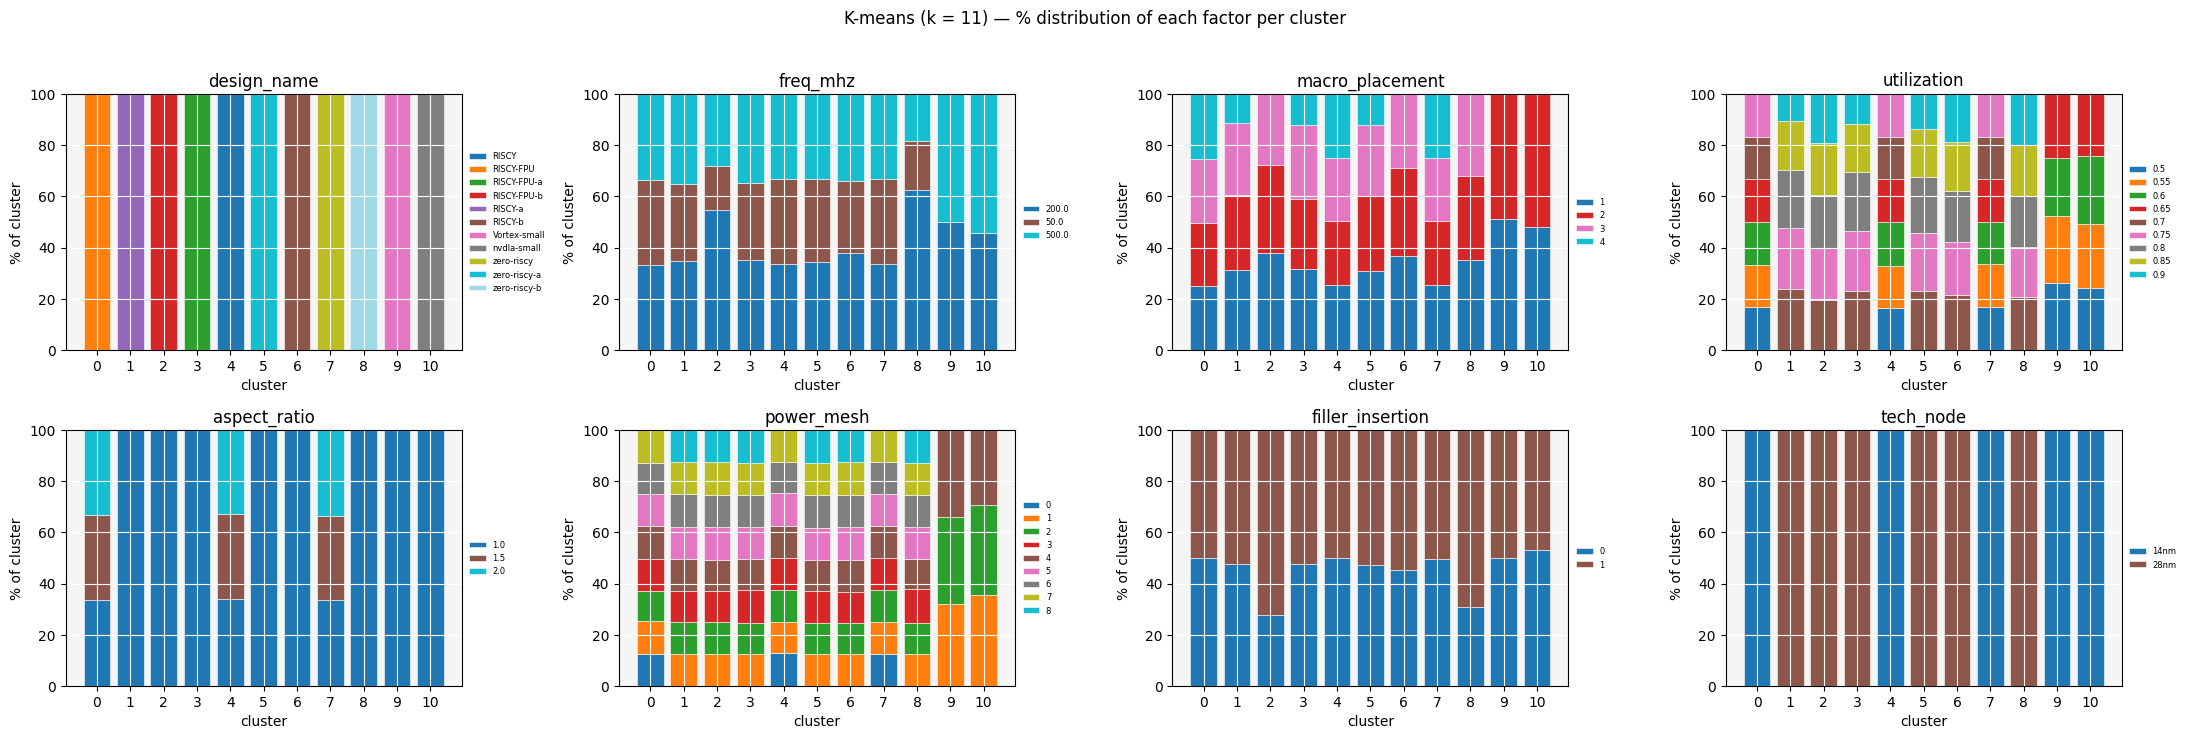

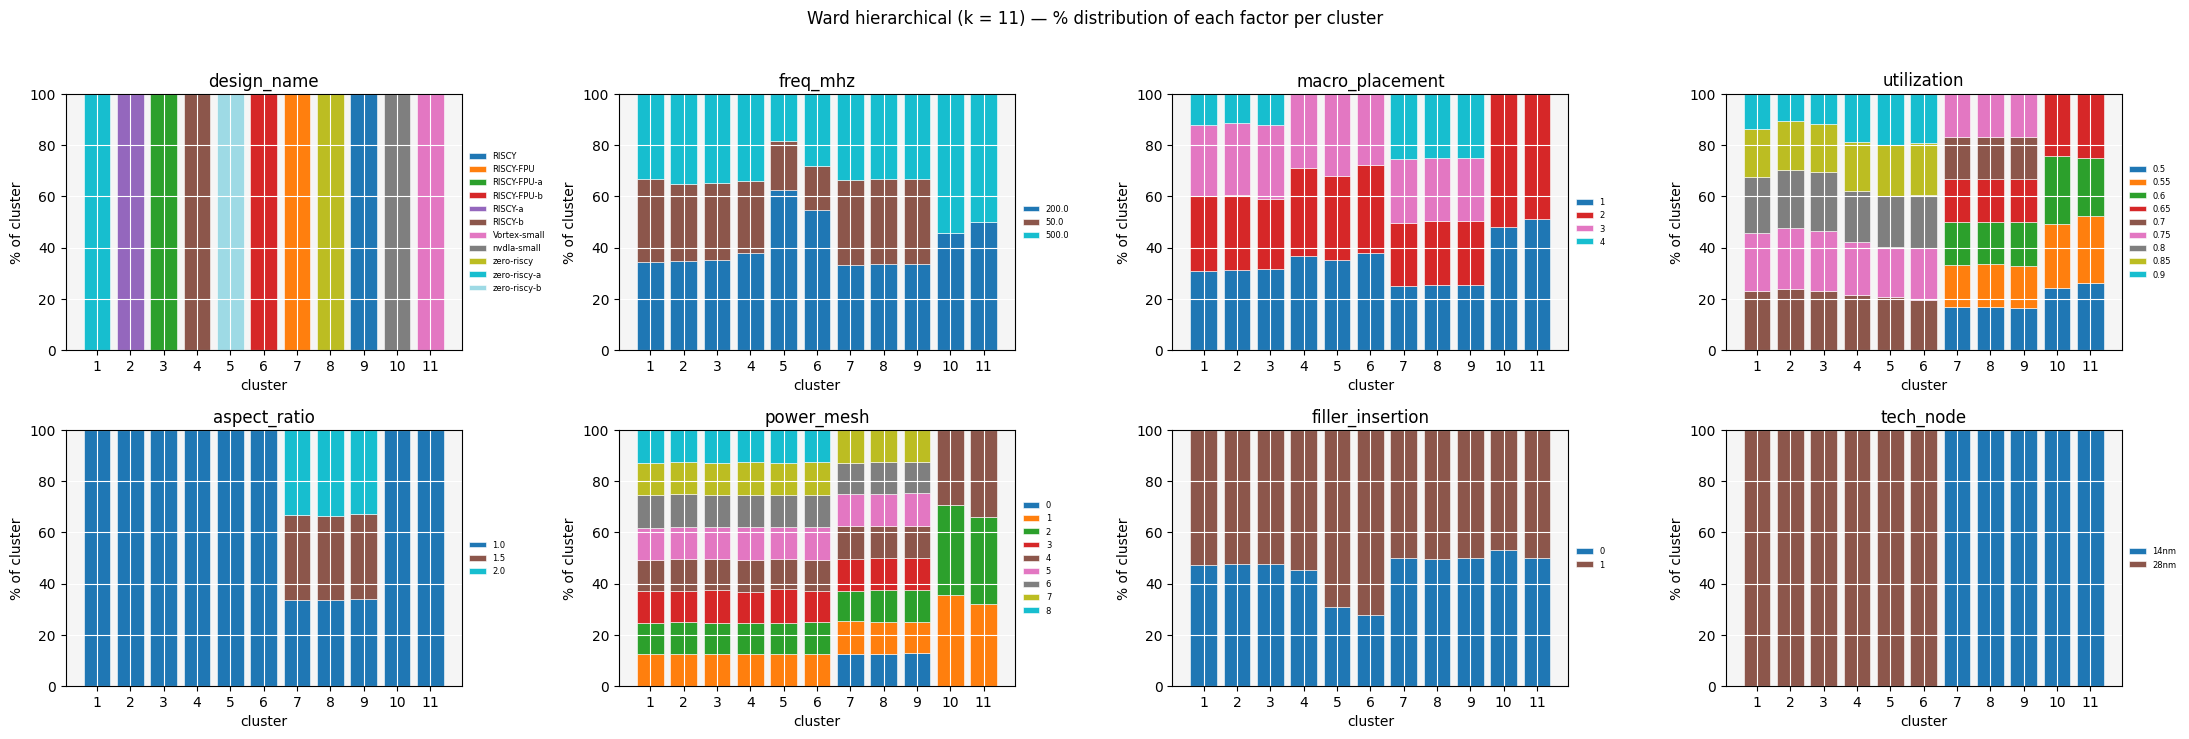

In [21]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

For each sample take its `k` nearest neighbors in the full PC space and,
for every factor, compute the fraction of neighbors that share the
sample's label. Averaged over all samples = local label purity. Compare
against chance (1 / n_levels) as `lift`.

For the merged dataset, watch `tech_node` — if it lifts near 2× (chance =
0.5, so agreement = 1.0), the geometry is *cleanly node-separated*.

kNN label agreement (k=12, merged N14+N28):

          factor  n_levels  agreement  chance  lift
     design_name        11      1.000   0.091 11.00
     utilization         9      0.527   0.111  4.74
      power_mesh         9      0.485   0.111  4.37
filler_insertion         4      0.999   0.250  4.00
 macro_placement         4      0.803   0.250  3.21
    aspect_ratio         3      0.973   0.333  2.92
        freq_mhz         3      0.961   0.333  2.88
       tech_node         2      1.000   0.500  2.00


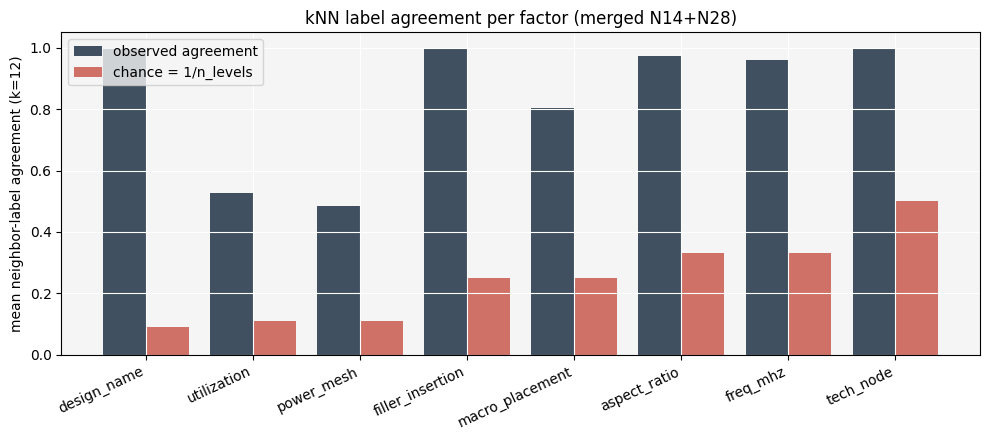

In [22]:
K_NN = 12

nn = NearestNeighbors(n_neighbors=K_NN + 1).fit(Z3)
_, idx = nn.kneighbors(Z3)
neighbor_idx = idx[:, 1:]

rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
    chance = 1.0 / df_full[f].nunique()
    rows.append({
        'factor':    f,
        'n_levels':  int(df_full[f].nunique()),
        'agreement': round(float(match.mean()), 3),
        'chance':    round(chance, 3),
        'lift':      round(float(match.mean()) / chance, 2),
    })
knn_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(f'kNN label agreement (k={K_NN}, merged N14+N28):\n')
print(knn_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(knn_df))
ax.bar(x - 0.2, knn_df['agreement'], width=0.4,
       color='#2c3e50', alpha=0.9, label='observed agreement')
ax.bar(x + 0.2, knn_df['chance'], width=0.4,
       color='#c0392b', alpha=0.7, label='chance = 1/n_levels')
ax.set_xticks(x); ax.set_xticklabels(knn_df['factor'], rotation=25, ha='right')
ax.set_ylabel(f'mean neighbor-label agreement (k={K_NN})')
ax.set_title('kNN label agreement per factor (merged N14+N28)')
ax.legend()
plt.tight_layout(); plt.show()

# Final verdict — merged N14 + N28

*Fill in with observed numbers after running the notebook.* Suggested
structure, mirroring the per-dataset notebooks:

## Which factor is the FL client axis?

Expected top of the ranking (per the predictions in the header):

1. `tech_node` — the cross-node axis.
2. `design_name` — 11 distinct designs, next-strongest signal.
3. Everything else near the noise floor.

Compare against the two per-dataset verdicts:

| finding | N28 | N14 | merged |
|---|---|---|---|
| Top factor | `design_name` (η² 0.505) | `design_name` (η² 0.421) | *fill in* |
| Second factor | flat band (0.083–0.098) | `filler_insertion` (η² 0.167) | *fill in* |
| kNN top lift | `design_name` 5.66 | `design_name` 5.00 | *fill in* |

## Sub-structure

If the merged best-silhouette k lands near `2 × n_design_families`, that's
the direct signature of a `tech_node × design` product structure. If it
lands lower, one of the two nodes is collapsing designs into shared
clusters.

## What ships to Phase 5

- **Cross-node FL scenario:** partition primarily on `tech_node`
  (2 super-clients), then substratify by `design_name`.
- **Node-agnostic FL scenario:** partition on `design_name` across both
  nodes, and treat `tech_node` as an intra-client covariate.

The choice depends on whether the CircuitNet 2.0 domain-shift analysis
(Analysis B in the CLAUDE.md workflow) shows large enough per-channel
distribution shift that a shared model can't cover both nodes.

# References

Same reference set as the per-dataset notebooks — see
`feature_axis_validation_N28.ipynb` or `_N14.ipynb` for the full
bibliography grouped by topic (CircuitNet datasets, PCA / clustering,
ARI/NMI, kNN label agreement, federated learning on non-IID data).

Merge-specific reading:

- Ben-David, S., Blitzer, J., Crammer, K., Kulesza, A., Pereira, F., &
  Vaughan, J. W. (2010). **A theory of learning from different domains.**
  *Machine Learning* 79, 151–175. — foundational framing for cross-node
  domain shift; the "tech_node as top PC" question this notebook asks is
  the practical form of their H-divergence measurement.
- Gretton, A., Borgwardt, K. M., Rasch, M. J., Schölkopf, B., & Smola, A.
  (2012). **A kernel two-sample test.** *JMLR* 13, 723–773. — MMD; the
  correct next-step statistic once this notebook says the two datasets
  live on different manifolds.